<a href="https://colab.research.google.com/github/Saranyadharani/Feedforward-Neural-Network-with-Backpropogation/blob/main/atri_ai_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

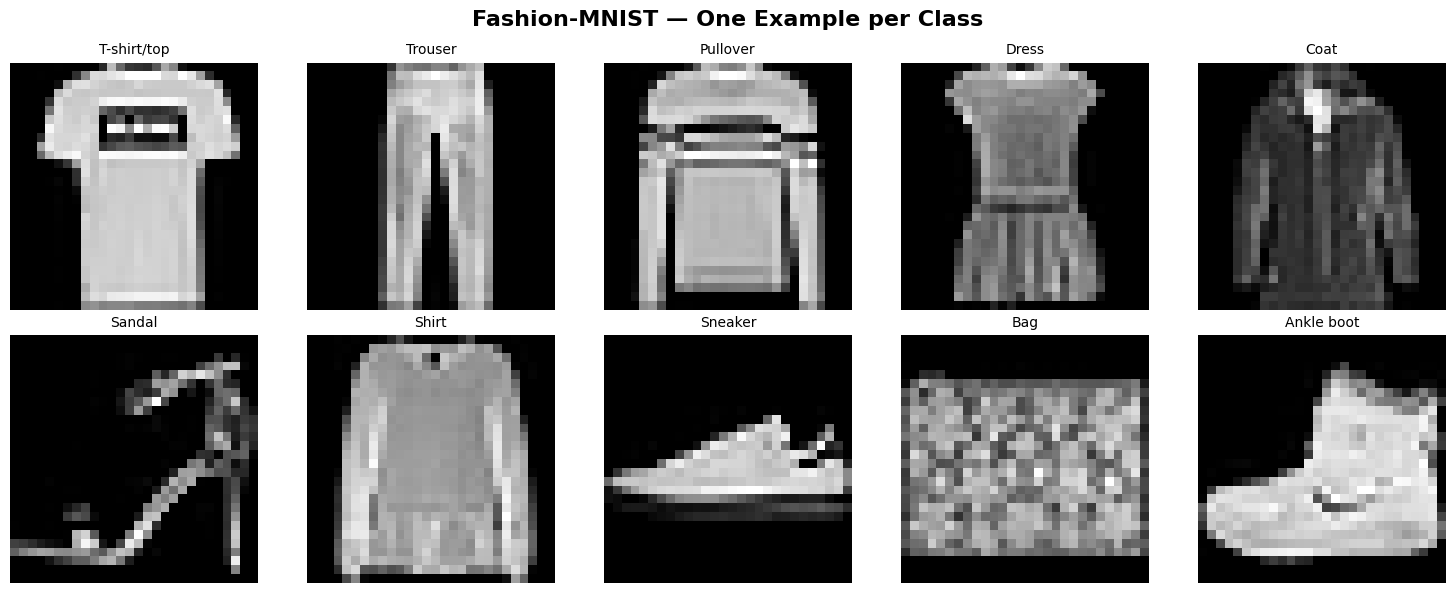

In [3]:
#Importing the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist

# Loading the  dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


# Defining Class names (0-9)
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Create 2x5 grid (2 rows and 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Fashion-MNIST — One Example per Class', fontsize=16, fontweight='bold')

# Find and plot one sample per class
for class_id in range(10):
    # Get first image belonging to this class
    idx = np.where(y_train == class_id)[0][0]

    # Setting the Grid position - row is calculated by taking quotient and columns by taking the remainders
    row, col = class_id // 5, class_id % 5

    # Display with crisp pixels
    axes[row, col].imshow(X_train[idx], cmap='gray', interpolation='nearest')
    axes[row, col].set_title(class_names[class_id], fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Flatten images (28x28 → 784)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Normalize pixel values (0-255 → 0-1)
X_train_norm = X_train_flat.astype(np.float32) / 255.0
X_test_norm = X_test_flat.astype(np.float32) / 255.0

# One-hot encode labels
def one_hot_encode(labels, num_classes=10):
    one_hot = np.zeros((labels.shape[0], num_classes))
    one_hot[np.arange(labels.shape[0]), labels] = 1
    return one_hot

y_train_onehot = one_hot_encode(y_train)
y_test_onehot = one_hot_encode(y_test)

class NeuralNetwork:
    """
    Flexible feedforward neural network.

    Usage:
        model = NeuralNetwork([784, 128, 64, 10], activation='relu')
        output, cache = model.forward(X_train_norm[:100])
    """

    def __init__(self, layer_sizes, activation='relu', weight_init='xavier'):
        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes) - 1
        self.activation_name = activation
        self.weight_init = weight_init

        # Initialize weights and biases
        self.weights = []
        self.biases = []

        for i in range(self.num_layers):
            input_size = layer_sizes[i]
            output_size = layer_sizes[i+1]

            if weight_init == 'xavier':
                limit = np.sqrt(6.0 / (input_size + output_size))
                w = np.random.uniform(-limit, limit, (input_size, output_size))
            else:  # random
                w = np.random.randn(input_size, output_size) * 0.01

            b = np.zeros((1, output_size))

            self.weights.append(w)
            self.biases.append(b)

    def activation(self, x):
        if self.activation_name == 'sigmoid':
            return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
        elif self.activation_name == 'tanh':
            return np.tanh(x)
        else:  # ReLU
            return np.maximum(0, x)

    def softmax(self, x):
        x_shifted = x - np.max(x, axis=1, keepdims=True)
        exp_x = np.exp(x_shifted)
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        cache = {'a0': X}
        current_input = X

        for i in range(self.num_layers):
            z = np.dot(current_input, self.weights[i]) + self.biases[i]
            cache[f'z{i+1}'] = z

            if i == self.num_layers - 1:
                a = self.softmax(z)
            else:
                a = self.activation(z)

            cache[f'a{i+1}'] = a
            current_input = a

        return current_input, cache

# Creating network with 3 hidden layers
model = NeuralNetwork(
    layer_sizes=[784, 128, 64, 32, 10],
    activation='relu',
    weight_init='xavier'
)

# Forward pass test
X_sample = X_train_norm[:5]
output, cache = model.forward(X_sample)

print("\nForward pass test:")
print(f"  Input shape: {X_sample.shape}")
print(f"  Output shape: {output.shape}")

# Print all 10 probabilities for the first image
print(f"\n  Probabilities for first image (all 10 classes):")
for i, prob in enumerate(output[0]):
    print(f"    Class {i}: {prob:.4f}")

print(f"\n  Sum of probabilities: {np.sum(output[0]):.4f} (should be 1.0)")
print(f"  All probabilities sum to 1: {np.allclose(np.sum(output, axis=1), 1.0)}")


Forward pass test:
  Input shape: (5, 784)
  Output shape: (5, 10)

  Probabilities for first image (all 10 classes):
    Class 0: 0.1472
    Class 1: 0.0774
    Class 2: 0.0763
    Class 3: 0.0896
    Class 4: 0.0618
    Class 5: 0.1297
    Class 6: 0.1018
    Class 7: 0.1074
    Class 8: 0.0909
    Class 9: 0.1181

  Sum of probabilities: 1.0000 (should be 1.0)
  All probabilities sum to 1: True
